# PSF focus modes: Airy vs defocus

The WCC observes in focus or deliberately defocused (+1 or +2 waves) to spread bright
stars over more pixels. This notebook renders the three PSF modes used by `wcc_sim`,
compares their profiles and encircled energy, and shows the effect of pointing jitter.

**Requirements:** the `py313` conda env kernel (needs `wcc_etc`). Fully offline — no
Gaia query is made.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import wcc_etc
import wcc_sim

plt.style.use('gks')
TEAL, RED, AMBER = '#00798c', '#d1495b', '#edae49'

print(f'wcc_sim {wcc_sim.__version__} | wcc_etc {wcc_etc.__version__}')

wcc_sim 0.1.0 | wcc_etc 0.6.0


## 1. Render the three PSFs

`render_oversampled_psf` asks `wcc_etc` for the PSF on a grid oversampled 11× relative
to the detector: the in-focus mode is an analytic Airy pattern, the defocused modes come
from Zemax Huygens data bundled with `wcc_etc`. Default stamp sizes are 129 detector px
(in focus) and 257 px (defocus, sized to the ~272 px extent of the Huygens data). Jitter
blur at the telescope's default level is included.

In [2]:
from wcc_sim.detectors import make_base_simulation
from wcc_sim.psf import DEFAULT_STAMP, render_oversampled_psf
from wcc_sim.render import bin_oversampled

OVER = 11
sim = make_base_simulation('zwo:r')
plate_mas = sim.sensor.get_plate_scale(sim.telescope).to('arcsec/pix').value * 1000

psfs = {}   # focus -> detector-sampled stamp (binned from the fine grid)
for focus in (0, 1, 2):
    fine = render_oversampled_psf(sim, focus, oversample=OVER)
    psfs[focus] = bin_oversampled(fine, OVER)
    print(f'focus={focus}: stamp {DEFAULT_STAMP[focus]} px '
          f'(fine grid {fine.shape[0]}^2), sum = {psfs[focus].sum():.6f}')
print(f'plate scale {plate_mas:.2f} mas/px')

focus=0: stamp 129 px (fine grid 1419^2), sum = 1.000000


focus=1: stamp 257 px (fine grid 2827^2), sum = 1.000000


focus=2: stamp 257 px (fine grid 2827^2), sum = 1.000000
plate scale 16.87 mas/px


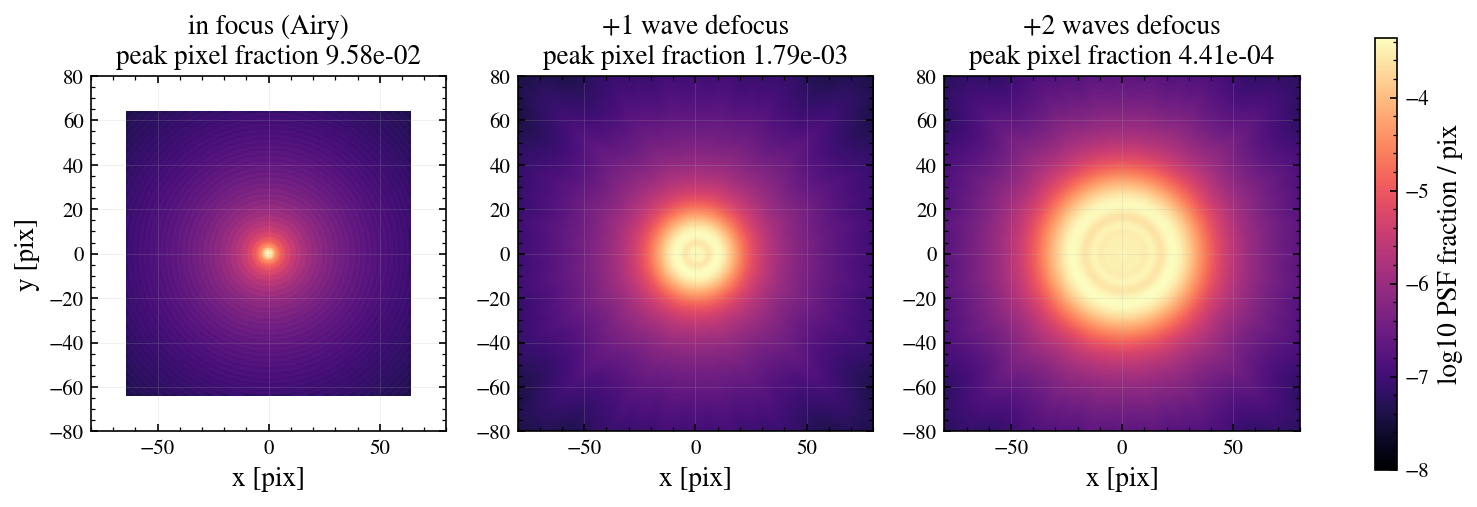

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
titles = ['in focus (Airy)', '+1 wave defocus', '+2 waves defocus']
for ax, (focus, title) in zip(axes, zip((0, 1, 2), titles)):
    p = psfs[focus]
    half = p.shape[0] // 2
    ext = np.array([-half, half, -half, half])
    im = ax.imshow(np.log10(np.maximum(p, 1e-12)), origin='lower',
                   cmap='magma', vmin=-8, vmax=np.log10(p.max()), extent=ext)
    ax.set_xlim(-80, 80); ax.set_ylim(-80, 80)
    ax.set_title(f'{title}\npeak pixel fraction {p.max():.2e}')
    ax.set_xlabel('x [pix]')
axes[0].set_ylabel('y [pix]')
fig.colorbar(im, ax=axes, label='log10 PSF fraction / pix', shrink=0.85)
plt.show()

The defocused PSFs are *annular*: the center is depressed and most of the energy lands
in a ring (radius ~29 px for +2 waves). That is why per-star saturation flags use a
32 px window rather than the central pixel alone.

## 2. Radial profiles and encircled energy

focus=0: EE50 within   1.4 px (    24 mas), EE90 within   5.0 px (    84 mas)
focus=1: EE50 within  10.4 px (   176 mas), EE90 within  17.0 px (   287 mas)
focus=2: EE50 within  22.1 px (   373 mas), EE90 within  31.3 px (   528 mas)


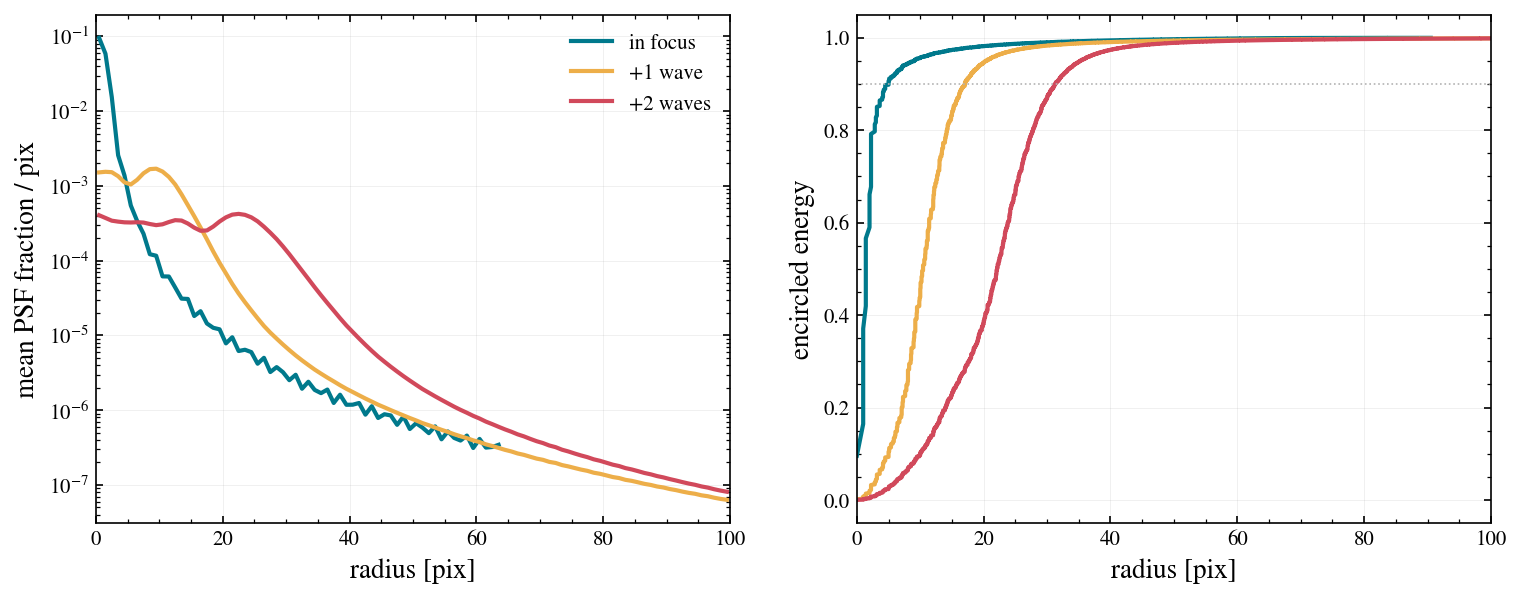

In [4]:
def radii(stamp):
    n = stamp.shape[0]
    y, x = np.mgrid[:n, :n] - n // 2
    return np.hypot(x, y)

def encircled_energy(stamp):
    r = radii(stamp).ravel()
    order = np.argsort(r)
    return r[order], np.cumsum(stamp.ravel()[order])

def ee_radius(r_sorted, ee, level):
    return np.interp(level, ee, r_sorted)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4))
for focus, color, label in [(0, TEAL, 'in focus'), (1, AMBER, '+1 wave'), (2, RED, '+2 waves')]:
    p = psfs[focus]
    r = radii(p)
    bins = np.arange(0, min(100, p.shape[0] // 2), 1.0)  # stay inside the stamp
    prof = [p[(r >= lo) & (r < lo + 1)].mean() for lo in bins]
    axL.semilogy(bins + 0.5, prof, color=color, label=label)
    rs, ee = encircled_energy(p)
    axR.plot(rs, ee, color=color, label=label)
    r50, r90 = ee_radius(rs, ee, 0.5), ee_radius(rs, ee, 0.9)
    print(f'focus={focus}: EE50 within {r50:5.1f} px ({r50*plate_mas:6.0f} mas), '
          f'EE90 within {r90:5.1f} px ({r90*plate_mas:6.0f} mas)')
axL.set_xlabel('radius [pix]'); axL.set_ylabel('mean PSF fraction / pix')
axL.set_xlim(0, 100); axL.legend()
axR.set_xlabel('radius [pix]'); axR.set_ylabel('encircled energy')
axR.set_xlim(0, 100); axR.axhline(0.9, color='0.7', lw=0.8, ls=':')
plt.show()

## 3. Jitter

Pointing jitter is a Gaussian blur applied at the fine plate scale. The default comes
from the `wcc_etc` telescope model; `jitter_sigma_mas=` overrides it per simulation
(`--jitter` on the CLI).

telescope default jitter: 10.0 mas (0.59 px)


jitter    0.0 mas: peak pixel 1.231e-01, EE50 radius 1.38 px
jitter   10.0 mas: peak pixel 9.578e-02, EE50 radius 1.41 px
jitter  150.0 mas: peak pixel 1.885e-03, EE50 radius 10.82 px


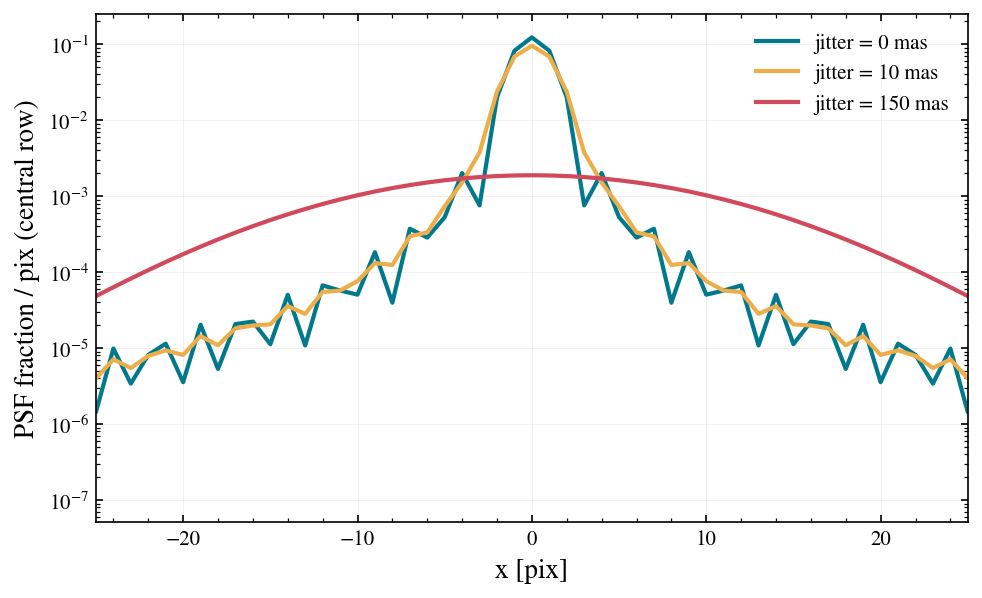

In [5]:
default_jitter = float(sim.telescope.jitter_sigma.to('mas').value)
print(f'telescope default jitter: {default_jitter:.1f} mas '
      f'({default_jitter / plate_mas:.2f} px)')

cuts = {}
for jit in (0.0, default_jitter, 150.0):
    fine = render_oversampled_psf(sim, 0, oversample=OVER, jitter_sigma_mas=jit)
    cuts[jit] = bin_oversampled(fine, OVER)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
for (jit, p), color in zip(cuts.items(), (TEAL, AMBER, RED)):
    n = p.shape[0]
    x = np.arange(n) - n // 2
    ax.semilogy(x, p[n // 2], color=color, label=f'jitter = {jit:.0f} mas')
    rs, ee = encircled_energy(p)
    print(f'jitter {jit:6.1f} mas: peak pixel {p.max():.3e}, '
          f'EE50 radius {ee_radius(rs, ee, 0.5):.2f} px')
ax.set_xlim(-25, 25)
ax.set_xlabel('x [pix]'); ax.set_ylabel('PSF fraction / pix (central row)')
ax.legend()
plt.show()

## Summary

- Three PSF modes: `focus=0` (analytic Airy), `1` and `2` (Zemax Huygens defocus data);
  all rendered 11×-oversampled and normalized to unit sum.
- Defocus spreads EE50 from ~1 px to tens of px and makes the PSF annular — the basis
  of the bright-star defocus strategy and the windowed saturation flag.
- Jitter blurs the core and lowers the peak pixel fraction; the telescope default is
  applied unless overridden.